# Metryki - Problem regresji

https://scikit-learn.org/stable/modules/model_evaluation.html

### Import bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
y_true = 100 + 20 * np.random.randn(50)
y_true

array([ 88.52781249, 114.0857903 , 131.10780998,  80.54159452,
       130.04528859,  64.96618769,  97.85067891,  89.54973202,
       113.16795124, 108.03681742, 104.50314647, 113.3294858 ,
       116.64208338, 122.16212607,  83.36332587, 115.37072819,
       122.62432931,  88.45056806, 115.42503596,  88.84615826,
        92.46890371, 120.54108324, 128.68938521, 114.18271614,
       114.07499659, 138.22812251, 115.39101102,  92.22201754,
        75.31559051, 104.23743646,  77.59711018,  85.0316252 ,
       112.29210051,  99.45909897, 127.54864988, 133.24149713,
       119.41197644, 119.72650001,  68.99608254, 115.63155618,
        75.87616642, 116.84330036, 115.09695032,  88.93369642,
       115.52649579,  91.15043376, 125.47592155, 113.47845275,
       110.88645446,  83.20722261])

In [3]:
y_pred = y_true + 10 * np.random.randn(50)
y_pred

array([ 95.94610285, 105.45642151, 128.19665849, 101.29380743,
       133.83192071,  64.47525867,  98.48239988,  96.57717723,
       136.52138135, 105.49083706, 120.87925535, 123.7400773 ,
       117.18286915, 124.58296913,  87.03672344, 107.48309455,
       125.17107707,  96.42220586, 114.23960148,  99.56556247,
        98.98742515, 115.34693274, 124.0940714 ,  91.96866148,
       113.21874724, 136.76004887,  97.85408157,  92.79297575,
        81.80082547,  91.35533335,  93.57469916,  81.08054018,
       112.69146964,  99.06415894, 126.01417883, 125.59084364,
       119.11993981, 133.76850618,  55.90209178, 132.38564643,
        84.44725266, 137.76374117, 110.56051537,  77.2669724 ,
       118.04615584, 101.29934037, 131.67920487, 116.62808422,
        88.42238814,  85.66749962])

In [4]:
results = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
results.head()

,y_true,y_pred
0,88.527812,95.946103
1,114.085790,105.456422
2,131.107810,128.196658
3,80.541595,101.293807
4,130.045289,133.831921


In [5]:
results['error'] = results['y_true'] - results['y_pred']
results.head()

,y_true,y_pred,error
0,88.527812,95.946103,-7.418290
1,114.085790,105.456422,8.629369
2,131.107810,128.196658,2.911151
3,80.541595,101.293807,-20.752213
4,130.045289,133.831921,-3.786632



### Interpretacja graficzna

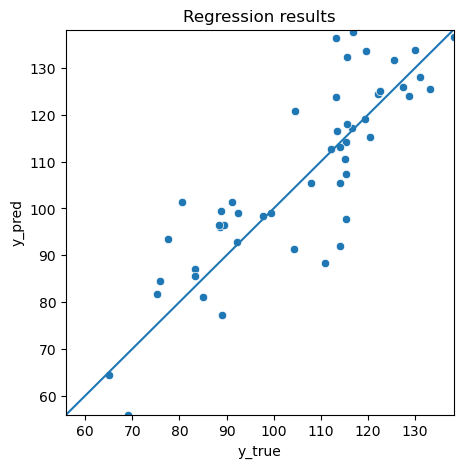

In [6]:
min_wartosc = results[['y_true', 'y_pred']].min().min()
max_wartosc = results[['y_true', 'y_pred']].max().max()

plt.figure(figsize=(5, 5))
sns.scatterplot(data=results, x='y_true', y='y_pred')
plt.plot([min_wartosc, max_wartosc], [min_wartosc, max_wartosc])

plt.xlabel('y_true')
plt.ylabel('y_pred')
plt.title('Regression results')
plt.xlim(min_wartosc, max_wartosc)
plt.ylim(min_wartosc, max_wartosc)
plt.show()

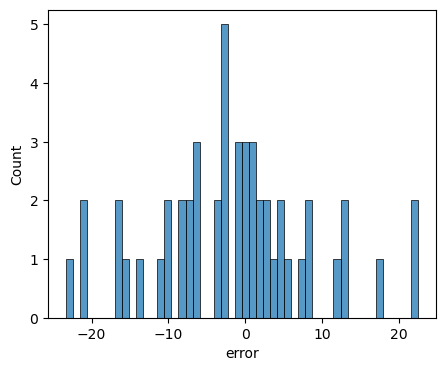

In [7]:
results['error'] = results['y_true'] - results['y_pred']

plt.figure(figsize=(5, 4))
sns.histplot(data=results, x='error', bins=50)

plt.xlabel('error')
plt.show()

## Mean Absolute Error - MAE - Średni błąd bezwzględny
$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_{true} - y_{pred}|$$

In [8]:
def mean_absolute_error(y_true, y_pred):
    return abs(y_true - y_pred).sum() / len(y_true)

mean_absolute_error(y_true, y_pred)

np.float64(7.726641549317103)

In [9]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_true, y_pred)

7.726641549317103

## Mean Squared Error - MSE - Błąd średniokwadratowy
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_{true} - y_{pred})^{2}$$

In [10]:
def mean_squared_error(y_true, y_pred):
    return ((y_true - y_pred) ** 2).sum() / len(y_true)

mean_squared_error(y_true, y_pred)

np.float64(105.00406805397881)

In [11]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_true, y_pred)

105.00406805397881

## Root Mean Squared Error - RMSE - Pierwiastek błędu średniokwadratowego
$$RMSE = \sqrt{MSE}$$

In [12]:
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(((y_true - y_pred) ** 2).sum() / len(y_true))

root_mean_squared_error(y_true, y_pred)

np.float64(10.247149264745723)

In [13]:
np.sqrt(mean_squared_error(y_true, y_pred))

np.float64(10.247149264745723)

## Max Error - Błąd maksymalny

$$ME = max(|y\_true - y\_pred|)$$ 

In [14]:
def max_error(y_true, y_pred):
    return abs(y_true - y_pred).max()

In [15]:
max_error(y_true, y_pred)

np.float64(23.353430111183485)

In [16]:
from sklearn.metrics import max_error

max_error(y_true, y_pred)

np.float64(23.353430111183485)

## R2 score - współczynnik determinacji
$$R2\_score = 1 - \frac{\sum_{i=1}^{N}(y_{true} - y_{pred})^{2}}{\sum_{i=1}^{N}(y_{true} - \overline{y_{true}})^{2}}$$

**R² score (współczynnik determinacji)** mówi, **jak dobrze model regresyjny wyjaśnia zmienność zmiennej zależnej**.

Najprościej:

* **R² = 1** oznacza model idealny,
* **R² = 0** oznacza, że model nie jest lepszy niż przewidywanie samej średniej,
* **R² < 0** oznacza, że model działa gorzej niż przewidywanie średniej.

Jak to interpretować:

* **R² = 0.80** → model wyjaśnia około **80% zmienności** danych,
* pozostałe **20%** to część niewyjaśniona przez model.

W praktyce:

* stosuje się do **regresji**,
* wysokie R² zwykle jest pożądane, ale **nie zawsze oznacza dobry model**,
* samo R² nie mówi, czy model jest poprawny statystycznie ani czy dobrze generalizuje.

Wzór (inaczej):
$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$
gdzie:

* (SS_{res}) — suma kwadratów błędów modelu,
* (SS_{tot}) — całkowita suma kwadratów odchyleń od średniej.

Czyli porównujemy:

* błąd modelu
  z
* błędem prostego przewidywania średniej.

**Uwaga**: Ujemne R² nie oznacza błędu obliczeń — zwykle oznacza po prostu, że model działa bardzo słabo.
Kiedy to się zdarza:

* model jest bardzo źle dopasowany,
* użyto niewłaściwych predyktorów,
* model jest testowany na nowych danych i słabo generalizuje,
* model został źle narzucony (np. zbyt uproszczony),
* czasem przy regresji bez wyrazu wolnego (interceptu),
* czasem przy małej liczbie instancji.


In [17]:
from sklearn.metrics import r2_score

r2_score(y_true, y_pred)

0.6846834683774966

In [18]:
def r2_score(y_true, y_pred):
    numerator = ((y_true - y_pred) ** 2).sum()
    denominator = ((y_true - y_true.mean()) ** 2).sum()
    try:
        r2 = 1 - numerator / denominator
    except ZeroDivisionError:
        print('Dzielenie przez zero')
    return r2

In [19]:
r2_score(y_true, y_pred)

np.float64(0.6846834683774966)

## Adjusted R² (skorygowany współczynnik determinacji)
robi to samo, ale **uwzględnia liczbę predyktorów** w modelu.

Dlaczego to ważne:

* zwykłe **R² prawie zawsze rośnie** albo przynajmniej nie maleje, gdy dodajesz nowe zmienne,
* nawet jeśli nowa zmienna jest praktycznie bezużyteczna.

To znaczy, że samo **R² może „nagradzać” przeładowany model**.

**Adjusted R²** wprowadza karę za zbyt dużą liczbę zmiennych:

* jeśli nowa zmienna naprawdę poprawia model, adjusted R² rośnie,
* jeśli nowa zmienna nie wnosi istotnej informacji, adjusted R² może zostać bez zmian albo spaść.

W skrócie:

* **R²**: „jak dobrze model pasuje?”
* **Adjusted R²**: „jak dobrze model pasuje, biorąc pod uwagę, ile zmiennych użyto?”

Wzory:

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

$$
Adjusted\ R^2 = 1 - (1 - R^2)\frac{n-1}{n-p-1}
$$

gdzie:

* n — liczba obserwacji,
* p — liczba predyktorów,
* $SS_{res}$ — suma kwadratów reszt,
* $SS_{tot}$ — całkowita suma kwadratów.

Praktyczna interpretacja:

* jeśli porównujemy **modele z różną liczbą zmiennych**, lepiej patrzeć na **adjusted R²**,
* jeśli opisujemy tylko dopasowanie jednego modelu, często podaje się **R²**.

Przykład:

* Model A: 3 zmienne, **R² = 0.80**
* Model B: 10 zmiennych, **R² = 0.86**

Na pierwszy rzut oka model B wygląda lepiej.
Ale jeśli po uwzględnieniu liczby zmiennych:

* Model A: **adjusted R² = 0.78**
* Model B: **adjusted R² = 0.74**

to znaczy, że dodatkowe zmienne raczej nie były warte dodania.